# Ridge Regression (from scratch)

Ridge shrinks coefficients with an $\ell_2$ penalty:

$$w_{RR} = (X^\top X + \lambda I)^{-1} X^\top y$$

We standardize features, mean-center the target, leave the intercept unpenalized, and choose $\lambda$ by **k-fold cross-validation** (an improvement over the original notebook's residual search on 50 rows).


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import (
    RidgeRegressor, load_housing_data, prepare_xy, train_val_split,
    select_lambda_cv, rmse, r2_score
)


Selected λ = 119.3777


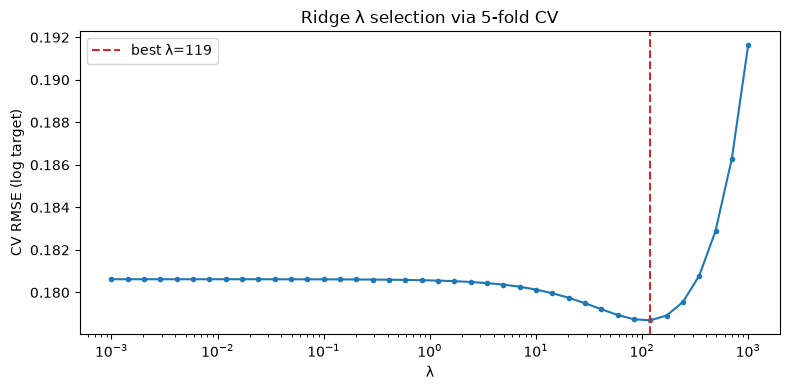

In [2]:
train, _ = load_housing_data()
X, y, feats = prepare_xy(train, log_target=True)
X_tr, X_va, y_tr, y_va = train_val_split(X, y, random_state=42)

best_lambda, grid, scores = select_lambda_cv(X_tr, y_tr)
print(f"Selected λ = {best_lambda:.4f}")

plt.figure(figsize=(8, 4))
plt.semilogx(grid, scores, marker="o", ms=3)
plt.axvline(best_lambda, color="#d62828", ls="--", label=f"best λ={best_lambda:.3g}")
plt.xlabel("λ"); plt.ylabel("CV RMSE (log target)"); plt.legend()
plt.title("Ridge λ selection via 5-fold CV")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "ridge_cv_curve.png", dpi=120)
plt.show()


In [3]:
model = RidgeRegressor(alpha=best_lambda).fit(X_tr, y_tr)
pred = model.predict(X_va)
print(dict(zip(feats, model.coef_.round(4))))
print(f"Val R²={r2_score(y_va, pred):.4f}  RMSE($)=${rmse(np.expm1(y_va), np.expm1(pred)):,.0f}")


{'OverallQual': np.float64(0.1133), 'GrLivArea': np.float64(0.0873), 'GarageCars': np.float64(0.0469), 'GarageArea': np.float64(0.0259), 'TotalBsmtSF': np.float64(0.0408), '1stFlrSF': np.float64(0.027), 'FullBath': np.float64(0.0092), 'TotRmsAbvGrd': np.float64(0.0257), 'YearBuilt': np.float64(0.0529), 'YearRemodAdd': np.float64(0.0484)}
Val R²=0.8194  RMSE($)=$29,387
